In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils import load_config, get_config_path, get_project_root, load_csv

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_colwidth", None)

In [18]:
model_name = "SVM_gridsearch_char_ngram_1-5_C_1"

In [19]:
config_path = get_config_path()
config = load_config(str(config_path))
project_root = get_project_root()
predictions_file = (project_root / config["data"]["local_predictions_file"].format(model_name=model_name)).resolve()
text_column = config["task"]["text_column"]
label_column = config["task"]["label_column"]


In [20]:
df = load_csv(predictions_file)

In [21]:
df.head()

,Text,Text_raw,Category,Prediction
0,putas religiones,En todas las putas religiones ahí nos vamos a ver 😏\n,0,0
1,jajaja mames pongas ponemos grupo bye putos,"JAJAJA no mames, aquí no pongas eso y por algo será, nos ponemos de acuerdo en el grupo mejor bye putos\n",0,1
2,sublime tweet denle 10 tacos 10 chelas cabrona jajajajajajajajaja,@USUARIO @USUARIO 👏👏👏SUBLIME TWEET! 🙌denle 10 tacos y 10 chelas a esta cabrona JAJAJAJAJAJAJAJAJA\n,0,0
3,quiero puto café llorar desestresarmeampno pensar,"Quiero un puto café, llorar, desestresarme&amp;no pensar en nada 🤦😫\n",0,0
4,cogiendo conque cogida metió cogida gay safesex,Cogiendo conQue buena cogida me metió 👌🏼🤤 #Cogida #Gay #SafeSex\n,0,0


## Compute evaluation metrics

In [22]:
y_test = df[label_column]
y_pred = df["Prediction"]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

Accuracy: 0.8166325835037491
Precision: 0.6631130063965884
Recall: 0.7369668246445498
F1 Score: 0.6980920314253648


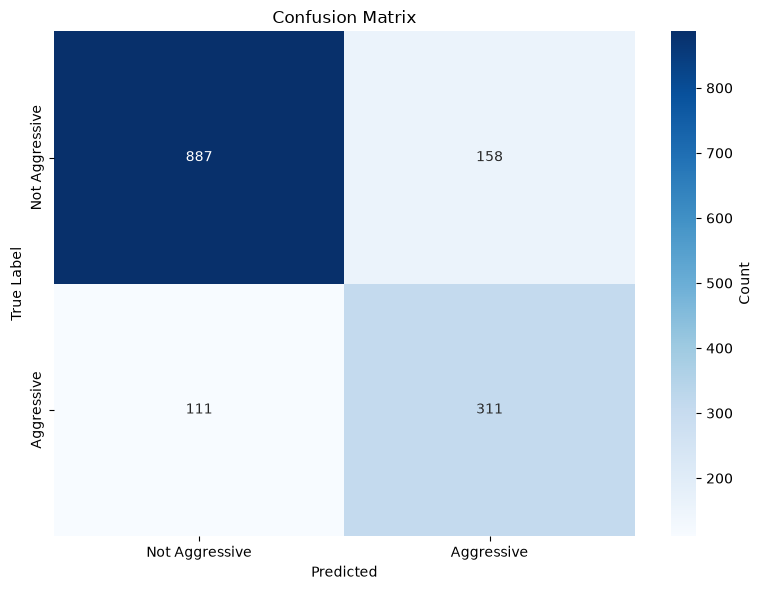

In [24]:
cm = confusion_matrix(df["Category"], df["Prediction"])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Aggressive", "Aggressive"],
    yticklabels=["Not Aggressive", "Aggressive"],
    cbar_kws={"label": "Count"},
)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1045
           1       0.66      0.74      0.70       422

    accuracy                           0.82      1467
   macro avg       0.78      0.79      0.78      1467
weighted avg       0.82      0.82      0.82      1467



## Error analysis

In [26]:
df[df["Category"] != df["Prediction"]][
    [text_column, "Text_raw", label_column, "Prediction"]
].head(20)

,Text,Text_raw,Category,Prediction
1,jajaja mames pongas ponemos grupo bye putos,"JAJAJA no mames, aquí no pongas eso y por algo será, nos ponemos de acuerdo en el grupo mejor bye putos\n",0,1
9,abuelita absoluta madre,"@USUARIO Para mi, mi abuelita es mi absoluta madre.\n",0,1
10,pinche edad andar leyendo pinches putas diapositivas verga chingadamadre,Y ya no están en la pinche edad para andar leyendo LAS PINCHES PUTAS DIAPOSITIVAS DE LA VERGA CHINGADAMADRE \n,0,1
13,encabronada pseudo feministas tontas iletradas avergüenza mujer preferiría falo niunamas,"Estoy muy encabronada con las pseudo feministas por tontas e iletradas, a veces me avergüenza ser mujer; preferiría tener un falo. #NiUnaMas\n",1,0
15,gracias catalanes habéis conseguido putos fachas dejen sentir vergüenza serlo,"Gracias catalanes, habéis conseguido que los putos fachas dejen de sentir vergüenza de serlo.\n",0,1
36,crees sexy estás gorda,Tu! La que te crees sexy y estás gorda!\n,1,0
42,funciona indiferencia ignoras vas verga l,Conmigo no funciona la indiferencia. A mí me ignoras y te vas a la verga .l.\n,1,0
45,traicionó pueblo méxico partido aliarse víboras prietas prometió combatir lanza alfonso romo,"Quién traicionó al pueblo de México y a su partido, para aliarse con las víboras prietas que prometió combatir; se lanza contra Alfonso Romo \n",0,1
50,puto asco personas amigos,que puto asco de personas :/ se dicen ser tus amigos !!\n,1,0
53,guadalajara monumento puto perro trabajo cdmx famoso televisa hambre raiting 911 circo,"Guadalajara tendrá monumento a un puto perro, por su trabajo en CDMX, que hizo famoso Televisa, en su hambre de raiting en el 9/11. #CIRCO\n",0,1


In [27]:
df[(df["Category"] == 0) & (df["Prediction"] == 1)][
    [text_column, "Text_raw", label_column, "Prediction"]
].head(20)

,Text,Text_raw,Category,Prediction
1,jajaja mames pongas ponemos grupo bye putos,"JAJAJA no mames, aquí no pongas eso y por algo será, nos ponemos de acuerdo en el grupo mejor bye putos\n",0,1
9,abuelita absoluta madre,"@USUARIO Para mi, mi abuelita es mi absoluta madre.\n",0,1
10,pinche edad andar leyendo pinches putas diapositivas verga chingadamadre,Y ya no están en la pinche edad para andar leyendo LAS PINCHES PUTAS DIAPOSITIVAS DE LA VERGA CHINGADAMADRE \n,0,1
15,gracias catalanes habéis conseguido putos fachas dejen sentir vergüenza serlo,"Gracias catalanes, habéis conseguido que los putos fachas dejen de sentir vergüenza de serlo.\n",0,1
45,traicionó pueblo méxico partido aliarse víboras prietas prometió combatir lanza alfonso romo,"Quién traicionó al pueblo de México y a su partido, para aliarse con las víboras prietas que prometió combatir; se lanza contra Alfonso Romo \n",0,1
53,guadalajara monumento puto perro trabajo cdmx famoso televisa hambre raiting 911 circo,"Guadalajara tendrá monumento a un puto perro, por su trabajo en CDMX, que hizo famoso Televisa, en su hambre de raiting en el 9/11. #CIRCO\n",0,1
57,fea criticando feas,"La fea criticando a ""feas"". 😂😂🤦🏻‍♀️\n",0,1
67,consejo semana confíen verga rodeados gente pinche culera felizmiercoles,"Consejo de la semana: no confíen en nadie a la verga, estamos rodeados de gente bien pinche culera. #FelizMiercoles\n",0,1
80,verga vecinos perros asquerosos alv,¿Por que verga mis vecinos son tan perros asquerosos? Alv\n,0,1
82,estúpidas golfas pirujas derechos arremete zurita mvs madres familia,"“¡Estúpidas, golfas, pirujas, ¡no tienen derechos!"", arremete Zurita en MVS contra madres de familia\n",0,1


**Notes:** After analyzing the model errors, I noticed a few points:

- There are some examples (row 60 in the dataframe above) in which the true category is 1 but the text doesn't appear to be aggressive (the model predicted the category as 0).
- The example of row 97 is Colombian spanish and it's very likely is not an aggressive expresion.
- It seems like the model is flagging text containing profanities as agressiveness 

## Check misclssifications with profanities

The confusion matrix above, show that the number of examples that the model flagged as agressive with true category not agressive is 158. Does the model flags all examples with profanities as agressive?

In [30]:
# Create a profanities list to check for false positives
profanities_list = [
    "pinche",
    "pinches",
    "puta",
    "putas",
    "puto",
    "putos",
    "pendejo",
    "pendeja",
    "chingada",
    "chingado",
    "chingar",
    "cabron",
    "cabrona",
    "culero",
    "culera",
    "verga",
    "mames",
    "madre",
    "maricon",
    "maricón",
    "mierda",
    "estúpidas",
    "golfas",
    "pirujas"
]

In [31]:
false_positives = df[(df["Category"] == 0) & (df["Prediction"] == 1)]